In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["font.size"] = 11

In [2]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

Shape: (400, 5)

Columns:
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

Missing Values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Data Types:
User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

Statistical Summary:


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [4]:
df_model = df.iloc[:, 2:].copy()

X = df_model[["Age", "EstimatedSalary"]]
y = df_model["Purchased"]

display(df_model.head())

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


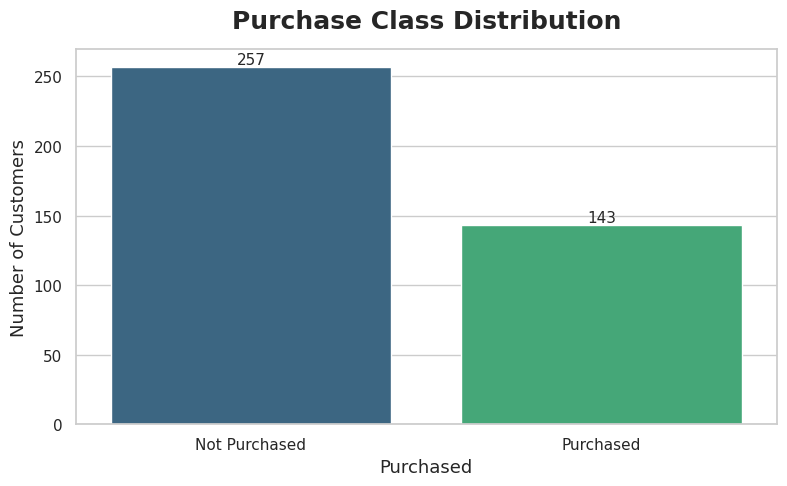

In [5]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_model,
    x="Purchased",
    hue="Purchased",
    palette="viridis",
    legend=False
)

ax.set_title("Purchase Class Distribution", pad=15, fontweight="bold")
ax.set_xlabel("Purchased")
ax.set_ylabel("Number of Customers")
ax.set_xticklabels(["Not Purchased", "Purchased"])

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.tight_layout()
plt.show()

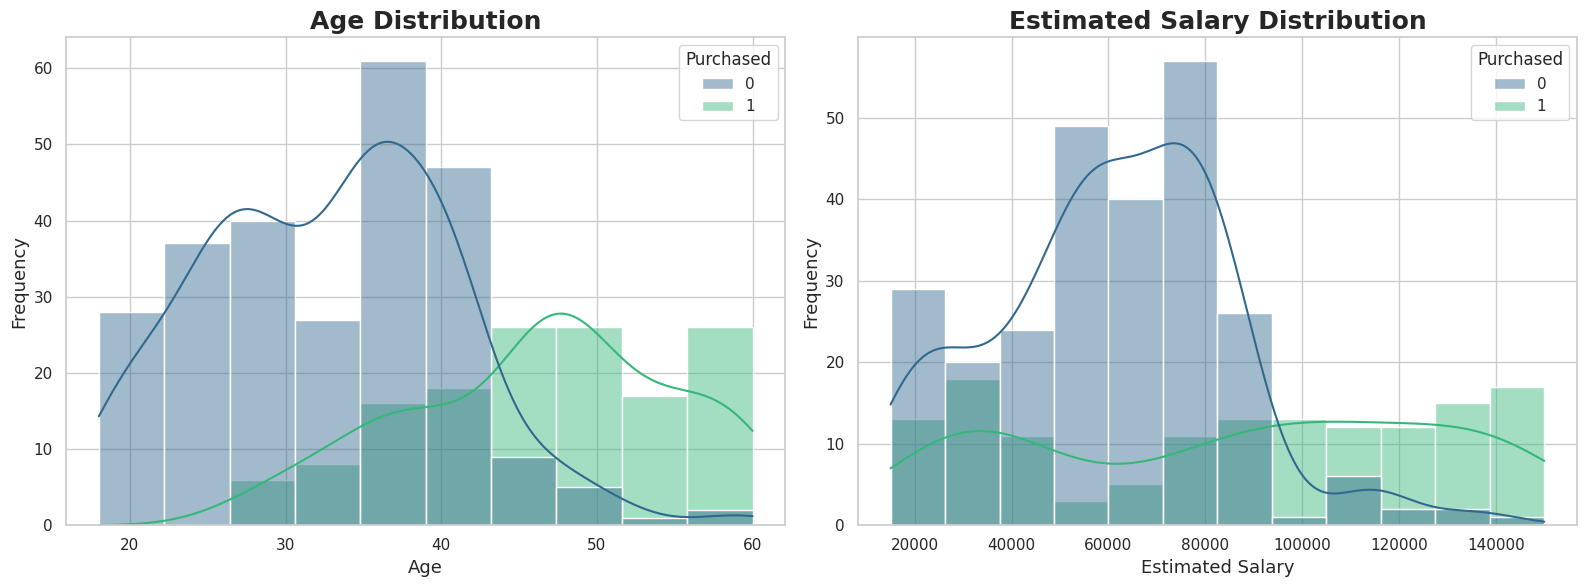

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df_model,
    x="Age",
    hue="Purchased",
    kde=True,
    palette="viridis",
    alpha=0.45,
    ax=axes[0]
)

axes[0].set_title("Age Distribution", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=df_model,
    x="EstimatedSalary",
    hue="Purchased",
    kde=True,
    palette="viridis",
    alpha=0.45,
    ax=axes[1]
)

axes[1].set_title("Estimated Salary Distribution", fontweight="bold")
axes[1].set_xlabel("Estimated Salary")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

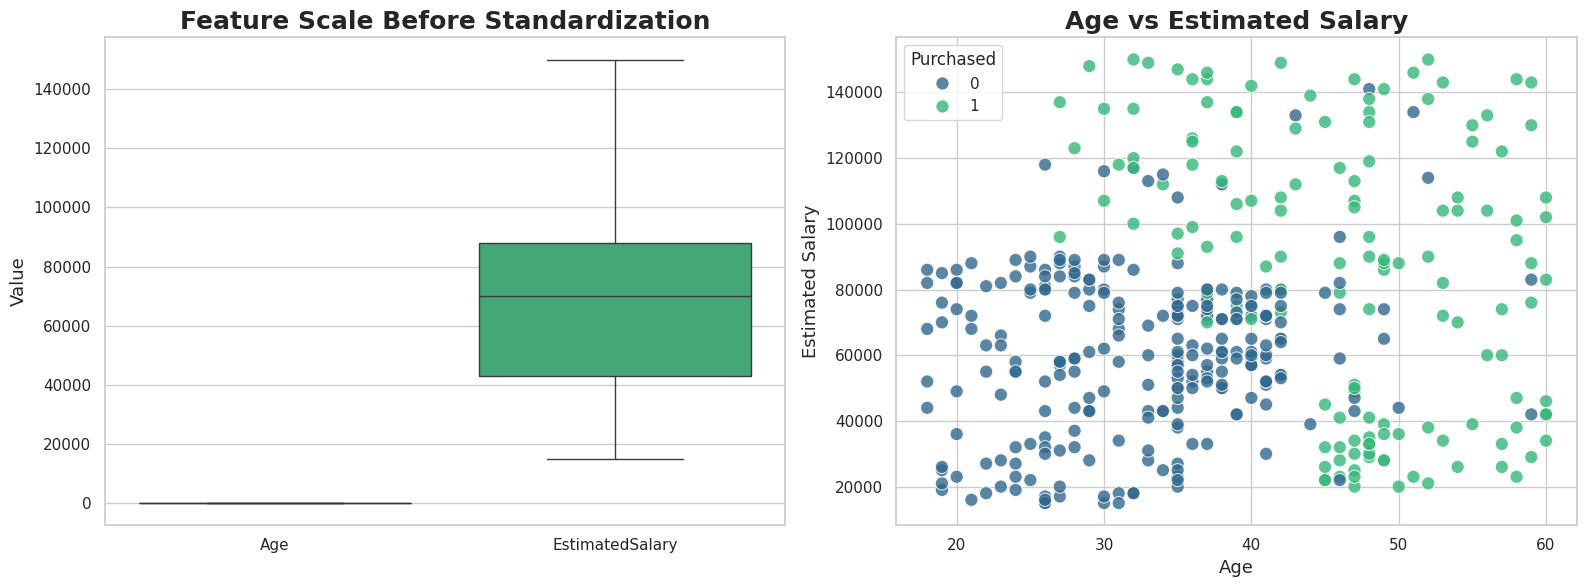

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=X,
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Feature Scale Before Standardization", fontweight="bold")
axes[0].set_ylabel("Value")

sns.scatterplot(
    data=df_model,
    x="Age",
    y="EstimatedSalary",
    hue="Purchased",
    palette="viridis",
    s=90,
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title("Age vs Estimated Salary", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Estimated Salary")

plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [9]:
model_unscaled = Sequential([
    Input(shape=(2,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_unscaled.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_unscaled = model_unscaled.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4750 - loss: 754.3757 - val_accuracy: 0.3625 - val_loss: 334.1513
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5063 - loss: 205.8482 - val_accuracy: 0.6375 - val_loss: 217.7628
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5312 - loss: 317.0894 - val_accuracy: 0.3625 - val_loss: 126.3718
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5437 - loss: 222.6106 - val_accuracy: 0.6375 - val_loss: 32.9156
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5875 - loss: 75.1102 - val_accuracy: 0.3625 - val_loss: 141.5630
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4563 - loss: 98.1535 - val_accuracy: 0.6375 - val_loss: 48.8582
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4750 - loss: 109.4897 - val_accuracy: 0.3625 - val_loss: 151.3740
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5188 - loss: 1

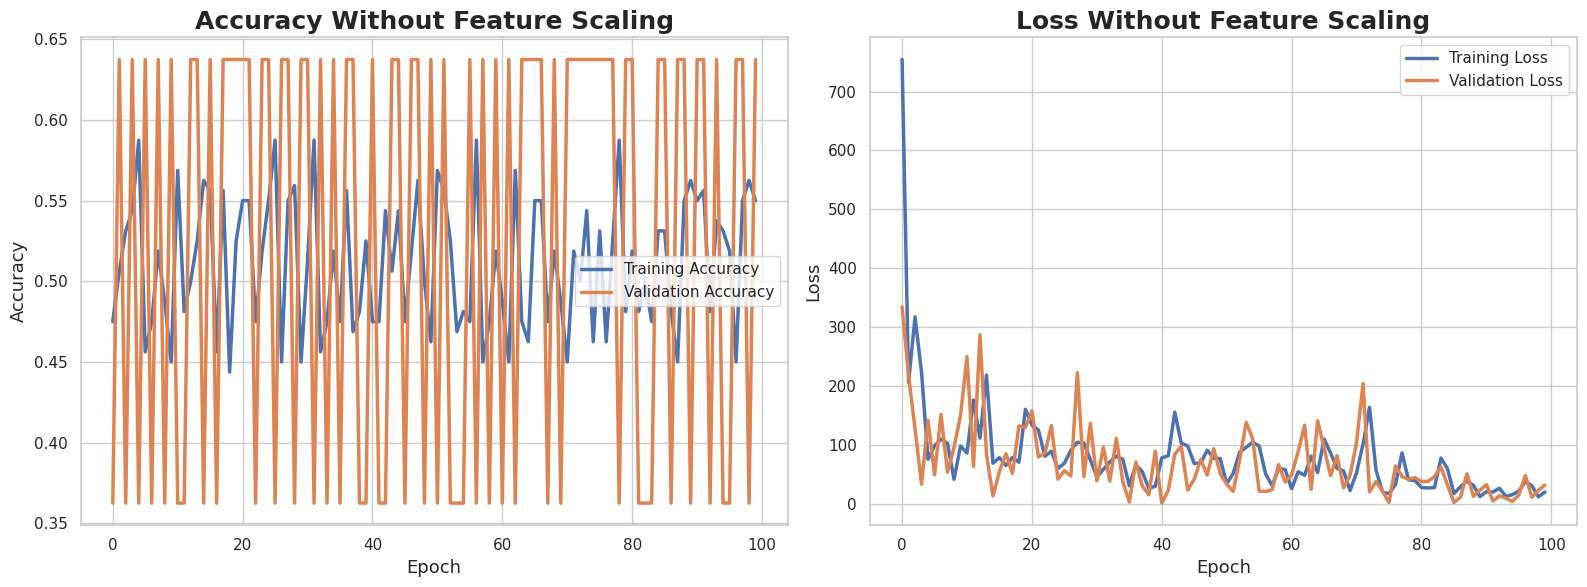

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    history_unscaled.history["accuracy"],
    linewidth=2.5,
    label="Training Accuracy"
)

axes[0].plot(
    history_unscaled.history["val_accuracy"],
    linewidth=2.5,
    label="Validation Accuracy"
)

axes[0].set_title("Accuracy Without Feature Scaling", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history_unscaled.history["loss"],
    linewidth=2.5,
    label="Training Loss"
)

axes[1].plot(
    history_unscaled.history["val_loss"],
    linewidth=2.5,
    label="Validation Loss"
)

axes[1].set_title("Loss Without Feature Scaling", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Accuracy without scaling: 0.6375

Classification Report:

              precision    recall  f1-score   support

           0       0.64      1.00      0.78        51
           1       0.00      0.00      0.00        29

    accuracy                           0.64        80
   macro avg       0.32      0.50      0.39        80
weighted avg       0.41      0.64      0.50        80



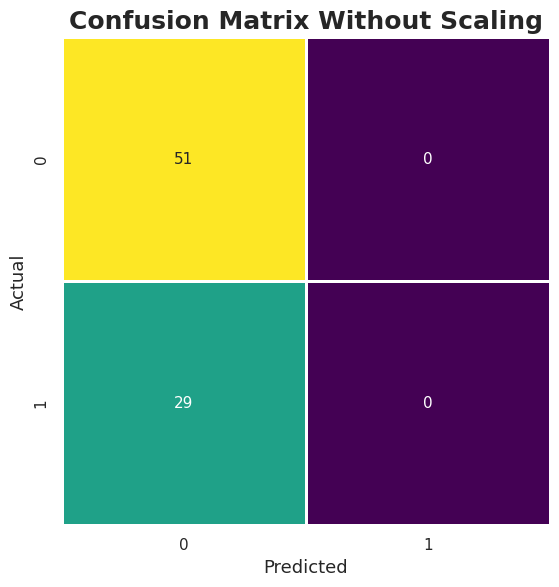

In [11]:
y_pred_unscaled_prob = model_unscaled.predict(X_test, verbose=0)
y_pred_unscaled = (y_pred_unscaled_prob >= 0.5).astype(int).ravel()

accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

print(f"Accuracy without scaling: {accuracy_unscaled:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_unscaled))

cm_unscaled = confusion_matrix(y_test, y_pred_unscaled)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_unscaled,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=1,
    square=True,
    cbar=False
)

plt.title("Confusion Matrix Without Scaling", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.transform(X)

scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=["Age", "EstimatedSalary"]
)

display(scaled_df.head())

,Age,EstimatedSalary
0,-1.030507,-0.353011
1,1.115874,2.048007
2,-0.250005,-0.295155
3,0.823186,-1.394416
4,0.140247,-0.324083


In [13]:
comparison = pd.DataFrame({
    "Original Mean": X_train.mean(),
    "Original Std": X_train.std(),
    "Scaled Mean": X_train_scaled.mean(axis=0),
    "Scaled Std": X_train_scaled.std(axis=0)
})

display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Age,37.5625,10.265862,-2.220446e-17,1.0
EstimatedSalary,70203.1250,34622.812930,0.000000e+00,1.0


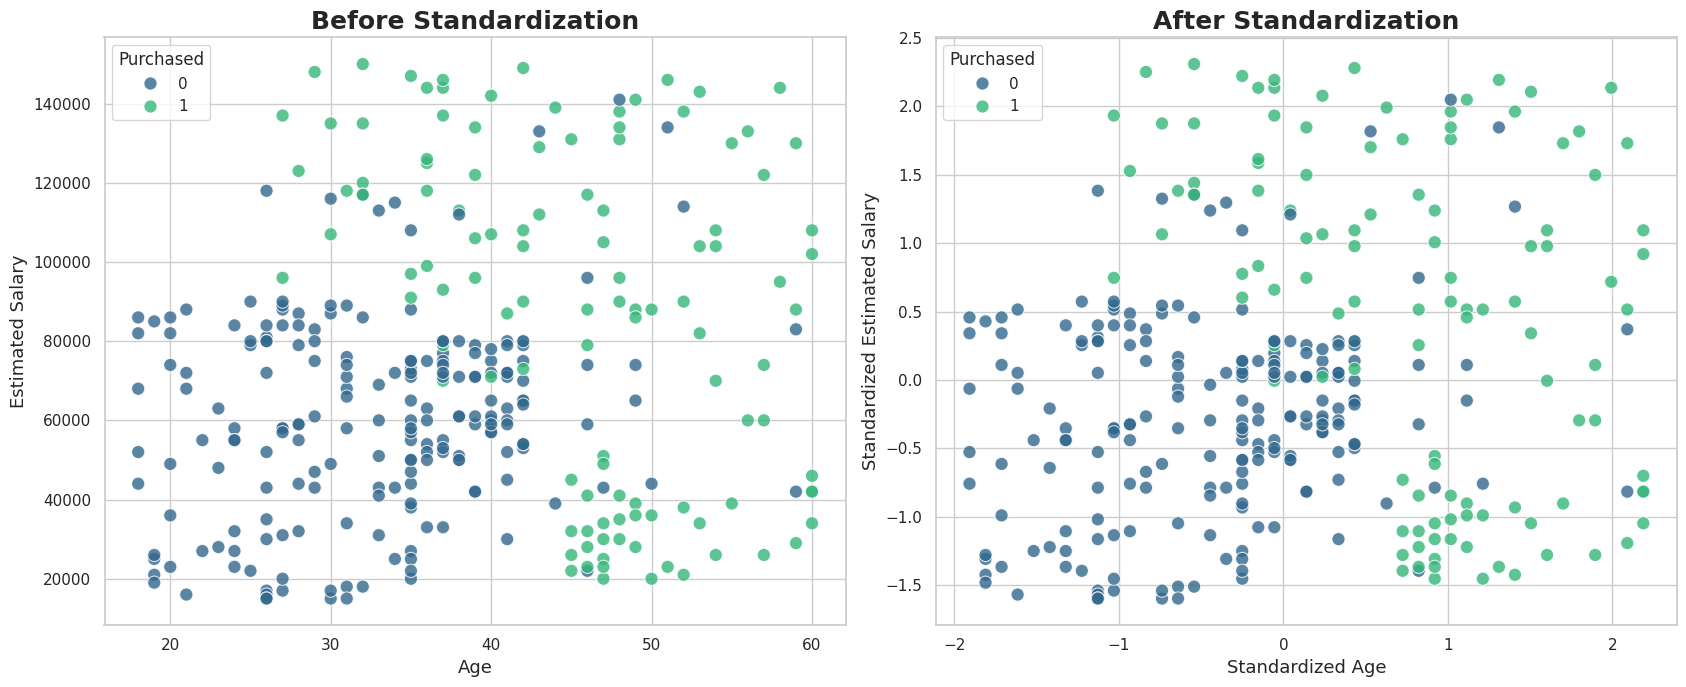

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(
    x=X_train["Age"],
    y=X_train["EstimatedSalary"],
    hue=y_train,
    palette="viridis",
    s=90,
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title("Before Standardization", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Estimated Salary")

sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=y_train,
    palette="viridis",
    s=90,
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title("After Standardization", fontweight="bold")
axes[1].set_xlabel("Standardized Age")
axes[1].set_ylabel("Standardized Estimated Salary")

plt.tight_layout()
plt.show()

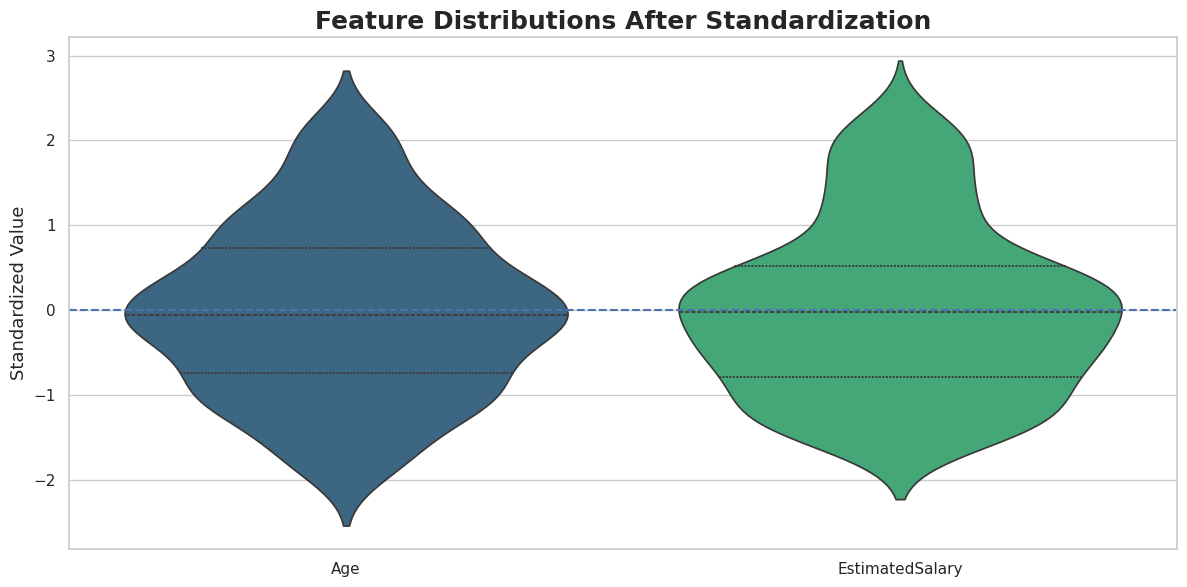

In [15]:
scaled_long = pd.DataFrame(
    X_train_scaled,
    columns=["Age", "EstimatedSalary"]
).melt(
    var_name="Feature",
    value_name="Scaled Value"
)

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=scaled_long,
    x="Feature",
    y="Scaled Value",
    hue="Feature",
    palette="viridis",
    legend=False,
    inner="quartile"
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title("Feature Distributions After Standardization", fontweight="bold")
plt.xlabel("")
plt.ylabel("Standardized Value")

plt.tight_layout()
plt.show()

In [16]:
model_scaled = Sequential([
    Input(shape=(2,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_scaled.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_scaled = model_scaled.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7000 - loss: 0.6642 - val_accuracy: 0.8875 - val_loss: 0.6037
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8250 - loss: 0.5844 - val_accuracy: 0.9250 - val_loss: 0.5041
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8313 - loss: 0.4967 - val_accuracy: 0.9125 - val_loss: 0.3915
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8531 - loss: 0.4133 - val_accuracy: 0.8875 - val_loss: 0.3038
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8656 - loss: 0.3537 - val_accuracy: 0.9125 - val_loss: 0.2490
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8938 - loss: 0.3144 - val_accuracy: 0.9250 - val_loss: 0.2166
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9000 - loss: 0.2888 - val_accuracy: 0.9250 - val_loss: 0.1981
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9031 - loss: 0.2726 - val_accuracy: 0.

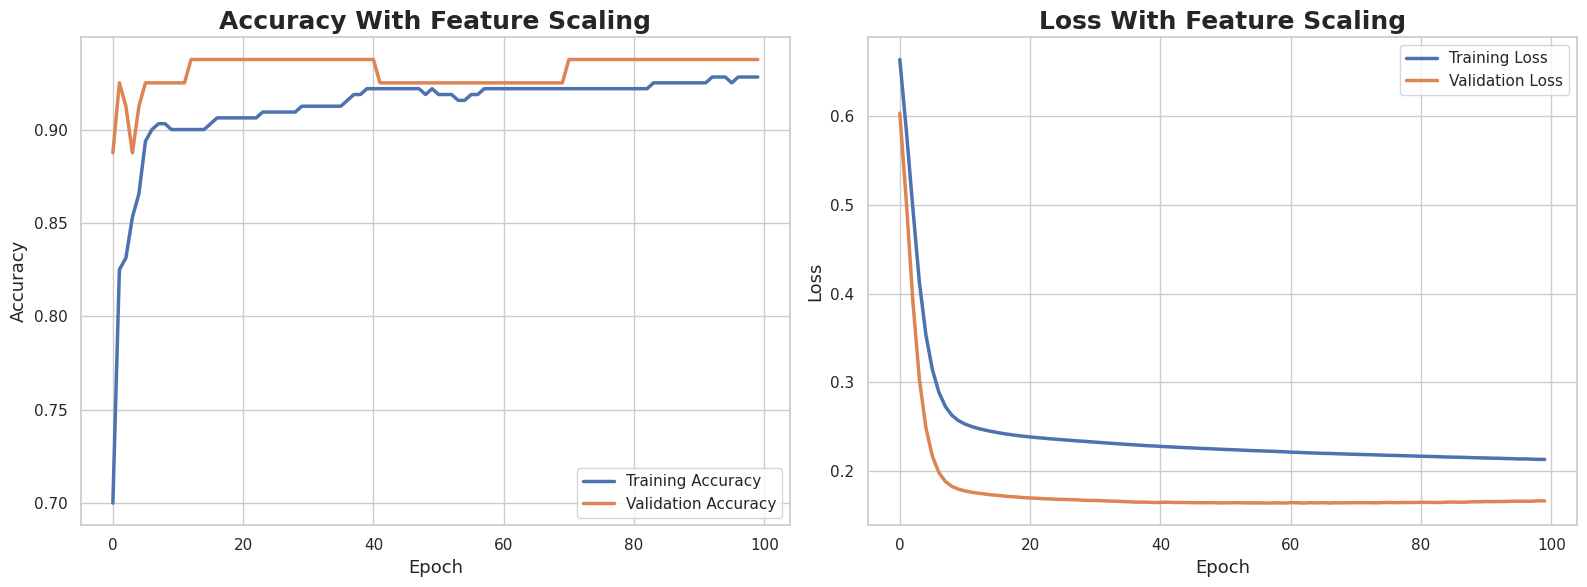

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    history_scaled.history["accuracy"],
    linewidth=2.5,
    label="Training Accuracy"
)

axes[0].plot(
    history_scaled.history["val_accuracy"],
    linewidth=2.5,
    label="Validation Accuracy"
)

axes[0].set_title("Accuracy With Feature Scaling", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history_scaled.history["loss"],
    linewidth=2.5,
    label="Training Loss"
)

axes[1].plot(
    history_scaled.history["val_loss"],
    linewidth=2.5,
    label="Validation Loss"
)

axes[1].set_title("Loss With Feature Scaling", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Accuracy with scaling: 0.9375

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        51
           1       0.93      0.90      0.91        29

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



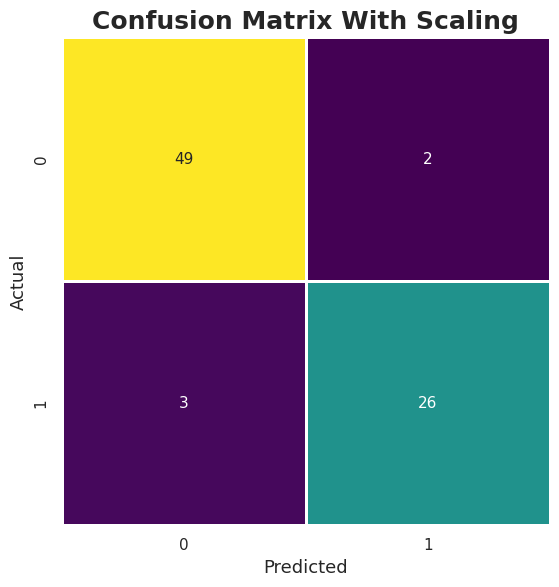

In [18]:
y_pred_scaled_prob = model_scaled.predict(X_test_scaled, verbose=0)
y_pred_scaled = (y_pred_scaled_prob >= 0.5).astype(int).ravel()

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy with scaling: {accuracy_scaled:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_scaled))

cm_scaled = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_scaled,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=1,
    square=True,
    cbar=False
)

plt.title("Confusion Matrix With Scaling", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

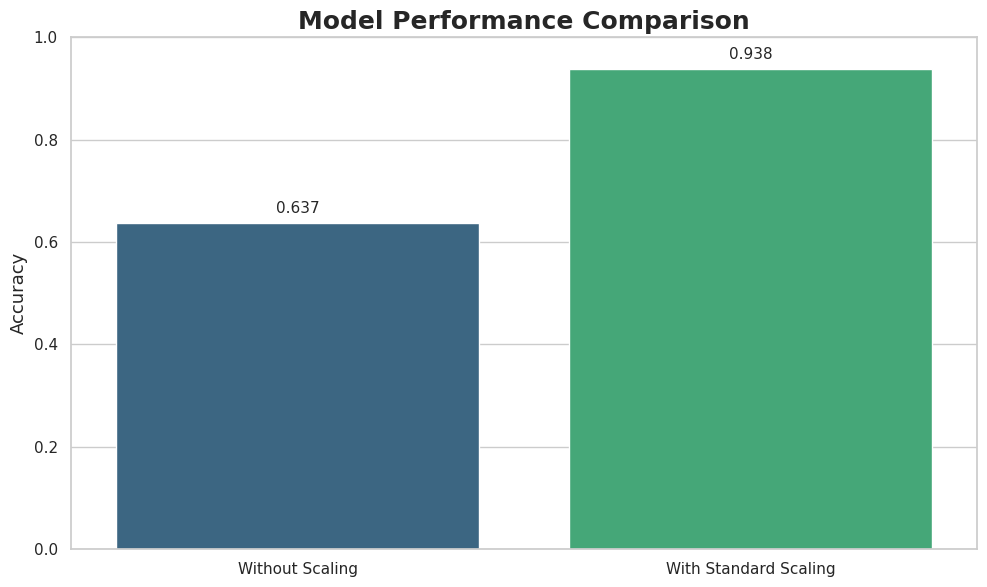

In [19]:
results = pd.DataFrame({
    "Model": ["Without Scaling", "With Standard Scaling"],
    "Accuracy": [accuracy_unscaled, accuracy_scaled]
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

ax.set_title("Model Performance Comparison", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5)

plt.tight_layout()
plt.show()

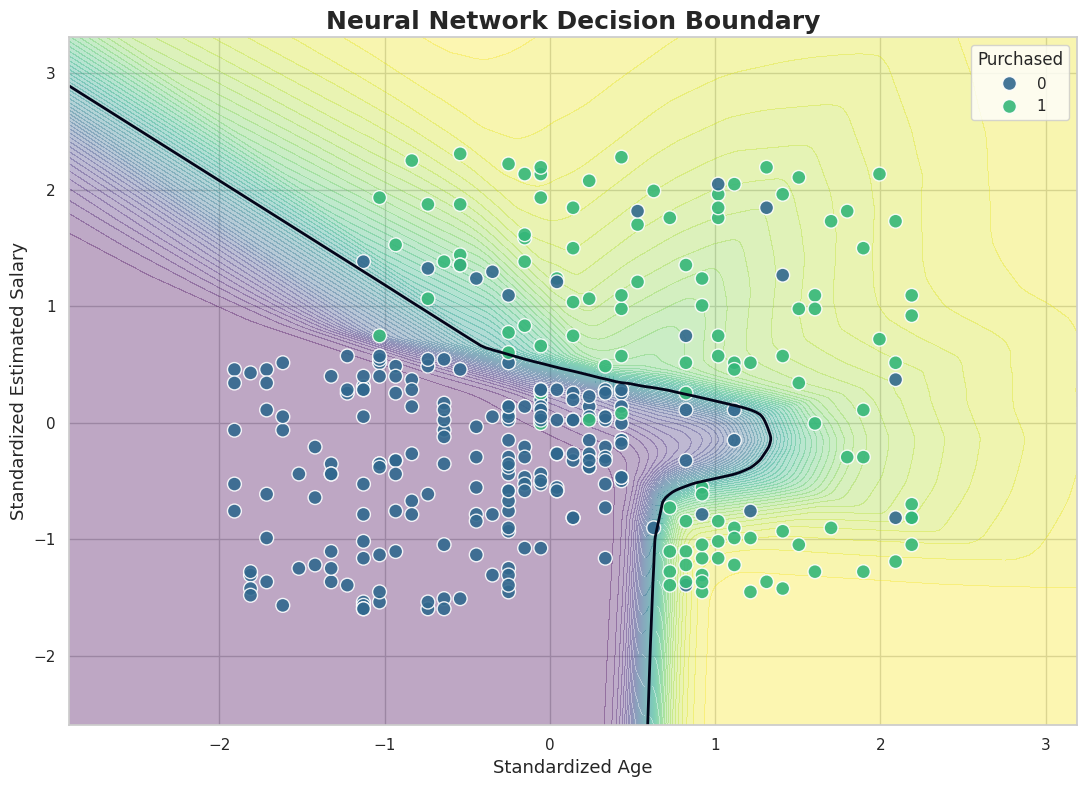

In [20]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probabilities = model_scaled.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(11, 8))

plt.contourf(
    xx,
    yy,
    probabilities,
    levels=50,
    cmap="viridis",
    alpha=0.35
)

plt.contour(
    xx,
    yy,
    probabilities,
    levels=[0.5],
    linewidths=2
)

sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=y_train,
    palette="viridis",
    s=100,
    edgecolor="white",
    linewidth=1,
    alpha=0.9
)

plt.title("Neural Network Decision Boundary", fontweight="bold")
plt.xlabel("Standardized Age")
plt.ylabel("Standardized Estimated Salary")
plt.legend(title="Purchased")

plt.tight_layout()
plt.show()

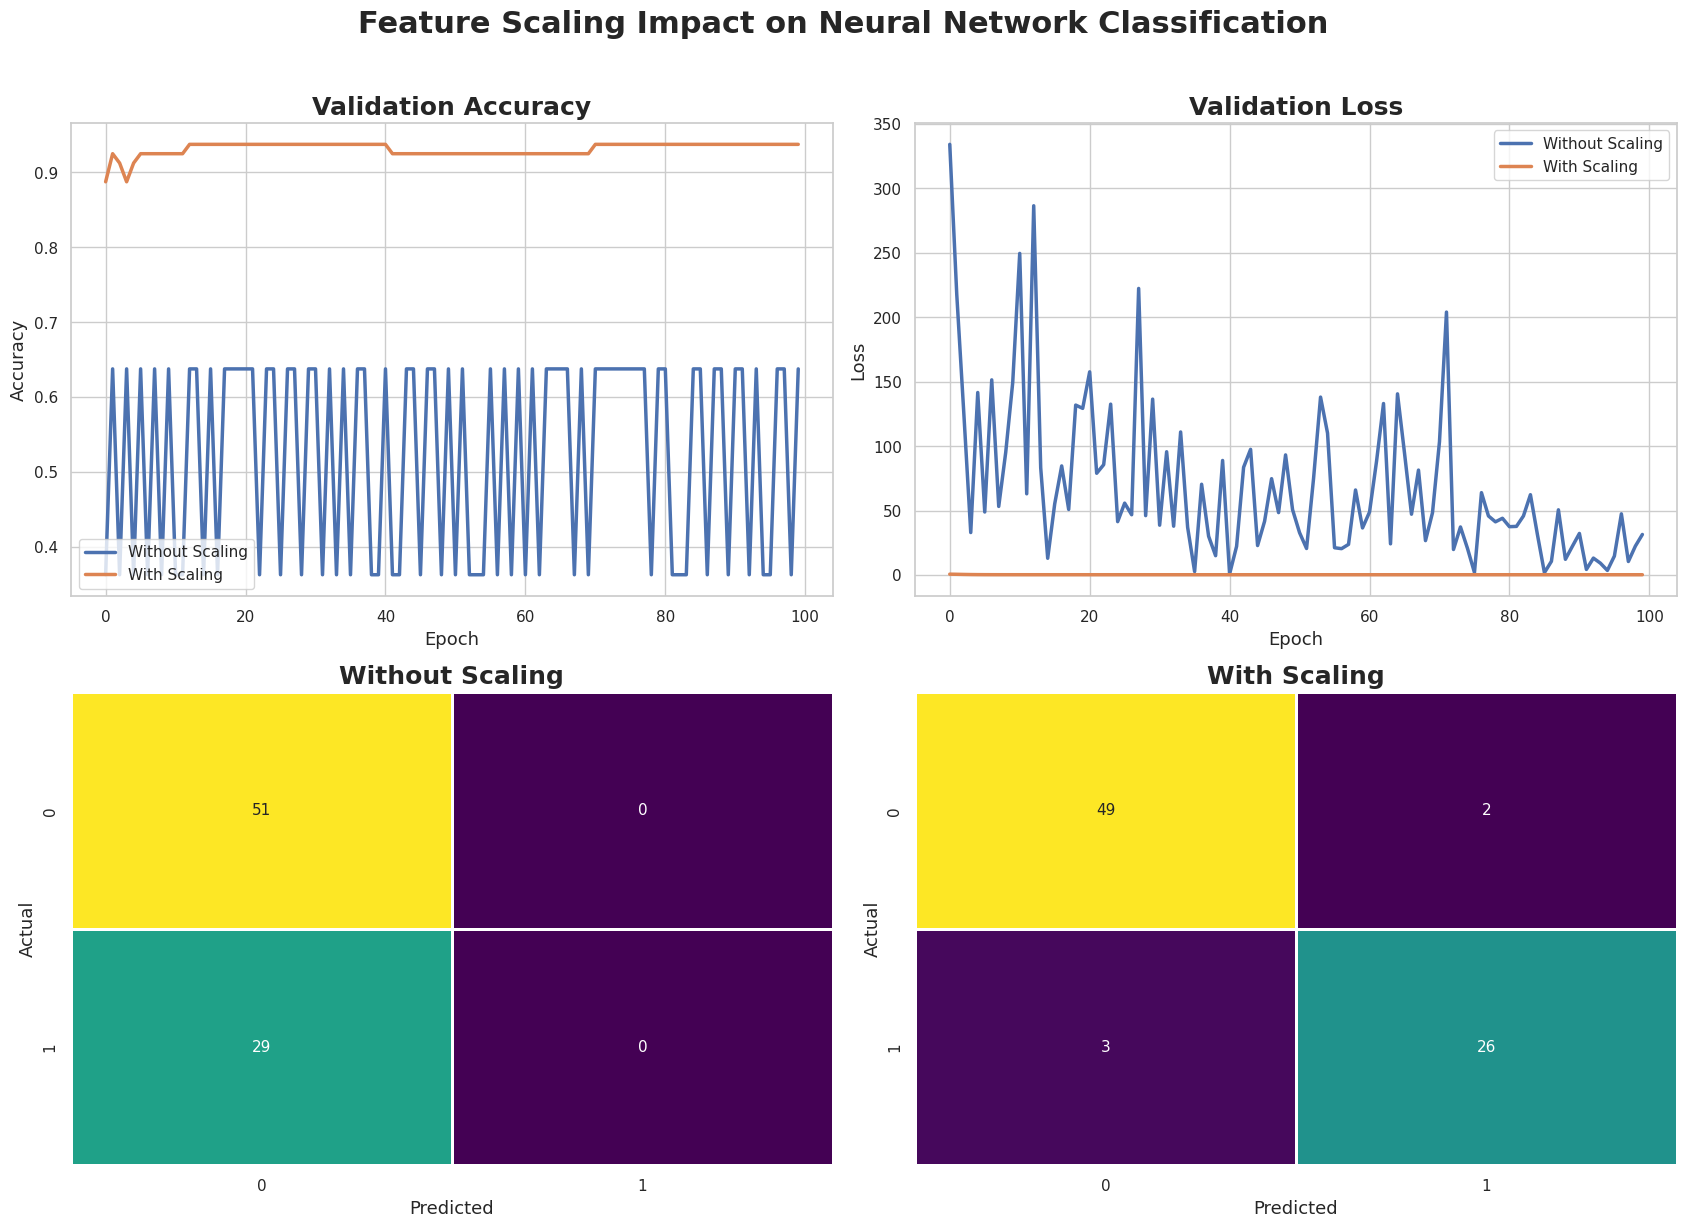

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

axes[0, 0].plot(
    history_unscaled.history["val_accuracy"],
    linewidth=2.5,
    label="Without Scaling"
)

axes[0, 0].plot(
    history_scaled.history["val_accuracy"],
    linewidth=2.5,
    label="With Scaling"
)

axes[0, 0].set_title("Validation Accuracy", fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

axes[0, 1].plot(
    history_unscaled.history["val_loss"],
    linewidth=2.5,
    label="Without Scaling"
)

axes[0, 1].plot(
    history_scaled.history["val_loss"],
    linewidth=2.5,
    label="With Scaling"
)

axes[0, 1].set_title("Validation Loss", fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

sns.heatmap(
    cm_unscaled,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=1,
    cbar=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Without Scaling", fontweight="bold")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")

sns.heatmap(
    cm_scaled,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=1,
    cbar=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("With Scaling", fontweight="bold")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

plt.suptitle(
    "Feature Scaling Impact on Neural Network Classification",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

In [22]:
final_summary = pd.DataFrame({
    "Metric": [
        "Unscaled Accuracy",
        "Scaled Accuracy",
        "Unscaled Final Validation Accuracy",
        "Scaled Final Validation Accuracy",
        "Unscaled Final Validation Loss",
        "Scaled Final Validation Loss"
    ],
    "Value": [
        accuracy_unscaled,
        accuracy_scaled,
        history_unscaled.history["val_accuracy"][-1],
        history_scaled.history["val_accuracy"][-1],
        history_unscaled.history["val_loss"][-1],
        history_scaled.history["val_loss"][-1]
    ]
})

display(final_summary)

,Metric,Value
0,Unscaled Accuracy,0.637500
1,Scaled Accuracy,0.937500
2,Unscaled Final Validation Accuracy,0.637500
3,Scaled Final Validation Accuracy,0.937500
4,Unscaled Final Validation Loss,31.401409
5,Scaled Final Validation Loss,0.166155
